In [1]:
import os
import glob
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Set plotting style
sns.set(style="whitegrid")
%matplotlib inline

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.16.1


In [2]:
# --- CONFIGURATION ---
LOGS_DIR = "logs_and_models"
FEATURES_DIR = "..\quantum_features"

GLOBAL_TEST_FEATURES = os.path.join(FEATURES_DIR, "global_test_features.npy")
GLOBAL_TEST_LABELS = os.path.join(FEATURES_DIR, "global_test_labels.npy")

CLASS_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# --- AUTO-DETECT LATEST MODEL ---
model_files = glob.glob(os.path.join(LOGS_DIR, "global_model_fednova_*.h5"))

if not model_files:
    raise FileNotFoundError("No models found! Run server.py first.")

LATEST_MODEL_PATH = max(model_files, key=os.path.getmtime)

print(f"Evaluation Mode: GLOBAL TEST SET")
print(f"Loading Data:    {GLOBAL_TEST_FEATURES}")
print(f"Loading Model:   {LATEST_MODEL_PATH}")

Evaluation Mode: GLOBAL TEST SET
Loading Data:    ..\quantum_features\global_test_features.npy
Loading Model:   logs_and_models\global_model_fednova_20260218_033144.h5


In [3]:
def load_global_test_data():
    if not os.path.exists(GLOBAL_TEST_FEATURES):
        print(f"ERROR: File not found: {GLOBAL_TEST_FEATURES}")
        return None, None

    print("Loading global test set...")
    X_test = np.load(GLOBAL_TEST_FEATURES)
    y_test = np.load(GLOBAL_TEST_LABELS)

    # 1. Flatten (if saved as 32x32x4)
    if len(X_test.shape) > 2:
        print(f"Flattening shape: {X_test.shape} -> ({X_test.shape[0]}, {32*32*4})")
        X_test = X_test.reshape(X_test.shape[0], -1)

    # 2. Normalize (CRITICAL FIX)
    # The model weights are tuned for scaled data (Mean=0, Std=1).
    # We must apply the same transformation to this test set.
    print("Applying StandardScaler...")
    scaler = StandardScaler()
    X_test = scaler.fit_transform(X_test)

    print(f"Data Loaded Successfully. Shape: {X_test.shape}")
    return X_test, y_test

X_test, y_test = load_global_test_data()

Loading global test set...
Applying StandardScaler...
Data Loaded Successfully. Shape: (2000, 4096)


In [4]:
def build_qcnn_architecture(input_shape, num_classes):
    """Reconstructs the exact architecture from model.py to allow weight loading."""
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.BatchNormalization(),

        # Layer 1: 1024
        layers.Dense(1024, kernel_initializer="he_uniform"),
        layers.LeakyReLU(negative_slope=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Layer 2: 512
        layers.Dense(512, kernel_initializer="he_uniform"),
        layers.LeakyReLU(negative_slope=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        # Layer 3: 256
        layers.Dense(256, kernel_initializer="he_uniform"),
        layers.LeakyReLU(negative_slope=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.15),

        # Layer 4: 128 (Output of the feature extractor part)
        layers.Dense(128, kernel_initializer="he_uniform"),
        layers.LeakyReLU(negative_slope=0.1),
        layers.BatchNormalization(),
        # Note: No dropout on the last dense layer in standard config

        # Softmax Head
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

# --- BUILD & LOAD ---
input_shape = (X_test.shape[1],)
model = build_qcnn_architecture(input_shape, 4)

# Compile (required for .evaluate)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(f"Loading weights from {LATEST_MODEL_PATH}...")
try:
    # load_weights ignores the 'quantization_config' error in the JSON
    model.load_weights(LATEST_MODEL_PATH)
    print("Weights loaded successfully.")
    
    # --- EVALUATE ---
    print("Running evaluation...")
    loss, acc = model.evaluate(X_test, y_test, verbose=1)
    
    # Predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print("\n" + "="*60)
    print("FINAL EVALUATION RESULTS")
    print("="*60)
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Loss:     {loss:.4f}")
    print("-" * 60)
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

except Exception as e:
    print(f"CRITICAL ERROR: {e}")
    print("Ensure the architecture in 'build_qcnn_architecture' matches your training code exactly.")

Loading weights from logs_and_models\global_model_fednova_20260218_033144.h5...
Weights loaded successfully.
Running evaluation...
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6973 - loss: 1.2368
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

FINAL EVALUATION RESULTS
Accuracy: 70.25%
Loss:     1.1995
------------------------------------------------------------
                  precision    recall  f1-score   support

    MildDemented       0.70      0.66      0.68       500
ModerateDemented       0.79      0.84      0.82       500
     NonDemented       0.79      0.60      0.68       500
VeryMildDemented       0.57      0.71      0.63       500

        accuracy                           0.70      2000
       macro avg       0.71      0.70      0.70      2000
    weighted avg       0.71      0.70      0.70      2000



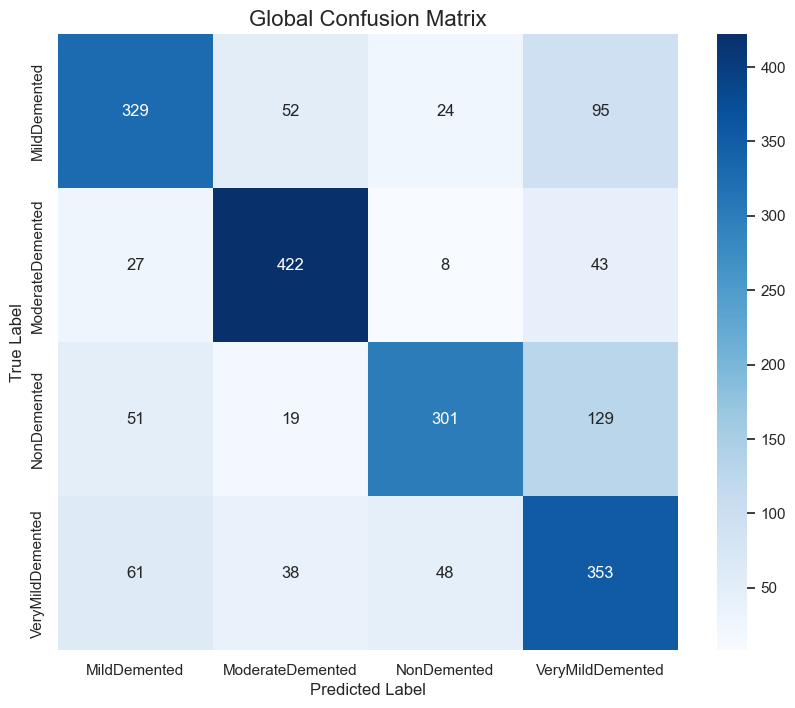

In [5]:
if X_test is not None:
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Global Confusion Matrix', fontsize=16)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()